### COMMON INSTRUCTIONS
Make sure to follow these instructions in order to ensure your submission is gradeable. If the automatic grading fails (check via Validate), no points are assigned!
1. Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).
2. Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE".
3. If you work in a group, please always work and submit in a shared server under the name of your group.
   If you work alone, then always work and submit on the server called "My Server".
4. Using Large Language Models and other AI tools is discouraged. Do not paste external code, as it can be tracked!
5. Do not upload notebooks. Always work in notebooks on the server.
6. Do not copy cells inside a notebook. Add a new cell and copy code from another cell if needed.

In [28]:
!tar czf myfiles.tar.gz ./*

tar: ./myfiles.tar.gz: file changed as we read it


---

# eXplainable AI, Assignment 2 
# Ulm University - Institute of Artificial Intelligence
# Summer Term 2026 - Due: Tue, Apr 28, 2025, 2pm - Moodle

# Data preparation

In this exercise sheet we will work with a classical regression dataset, where housing prices are predicted from different numerical features of the house. 
Please run the code below to load and prepare the dataset.

In [29]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

!pip3 install pandas
import pandas as pd
!pip3 install scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression  # needed for linear regression models below
!pip3 install numpy
import numpy as np
!pip3 install matplotlib
import matplotlib.pyplot as plt

dataset = pd.read_csv("housing_prices.csv", index_col=None)

FEATURE_COLUMNS = ['N_of_bedrooms', 'N_of_bathrooms', 'size_living',
       'size_lot', 'N_of_floors', 'condition', 'size_basement', 'yr_built']
TARGET_COLUMNS = ['price']

dataset[FEATURE_COLUMNS].head()
dataset[TARGET_COLUMNS].head()

X_train, X_test, y_train, y_test = train_test_split(
                                                dataset[FEATURE_COLUMNS],
                                                dataset[TARGET_COLUMNS],
                                                train_size=0.80,
                                                random_state=1337
)

,N_of_bedrooms,N_of_bathrooms,size_living,size_lot,N_of_floors,condition,size_basement,yr_built
0,3,1.00,109.63,524.90,1.0,3,0.00,1955
1,3,2.25,238.76,672.80,2.0,3,37.16,1951
2,2,1.00,71.54,929.03,1.0,3,0.00,1933
3,4,3.00,182.09,464.52,1.0,5,84.54,1965
4,3,2.00,156.08,750.66,1.0,3,0.00,1987


,price
0,221900.0
1,538000.0
2,180000.0
3,604000.0
4,510000.0


# 1. Linear Regression (6 pts)
In the following we will have a closer look at the influence of data scale and its impact on the difference between direct coefficient values and the feature effects.

## 1.1 Inspecting Parameters $\theta$ of Linear Regressors (1.5 pts)
Using the sklearn [linear regression model](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html), train two versions of a linear regressor: one without standardized data and one where the data is standardized (e.g., using scikit learn `StandardScaler`).
Then print out coefficients and intercepts of the two trained linear models.

Remark: The scaling is not only applied to the inputs, but also the outputs are standardized. What are the different effects of (e.g., down-)scaling inputs and (e.g., down-)scaling outputs on the learned coefficients?

In [30]:
# non-standardized regressor
regression: LinearRegression = None
intercept: np.float64 = None
coefficients: np.ndarray = None
# YOUR SOLUTION HERE
x_in = dataset[FEATURE_COLUMNS];
regression = LinearRegression().fit(X_train, y_train)
intercept = regression.intercept_
coefficients = regression.coef_
print("Regular (without standardized data):\nintercept:", intercept)
print("coefficients:", coefficients)

print('\n\n')

# standardized regressor
regression_scaled: LinearRegression = None
intercept_scaled: np.float64 = None
coefficients_scaled: np.ndarray = None
# YOUR SOLUTION HERE
from sklearn.preprocessing import StandardScaler
scaler_in = StandardScaler() #input data scaler
scaler_out = StandardScaler() #output data scaler

X_train_scaled = scaler_in.fit_transform(X_train)
y_train_scaled = scaler_out.fit_transform(y_train)

regression_scaled = LinearRegression().fit(X_train_scaled, y_train_scaled);
intercept_scaled = regression_scaled.intercept_
coefficients_scaled = regression_scaled.coef_

print("Scaled (standardized data in/out):\nintercept:", intercept_scaled)
print("coefficients:", coefficients_scaled)

# Answer to the question: The effects of (down-)scaling the in/out-puts appears to do the following to:
# coefficients: neatly bounds the values of coefficients within [-1,1] (highest positive value ~0.772, highest negative ~-0.2579
# this appears to give us more readily human-readable and explainable cofficient weights i.e. "coefficient 1 is about 1/5 negative, whereas coefficient 3 is about 3/4 positive for determining this feature.."
# intercept: the initial output value for all input values being zero seems to be effectively zero (x^-16 for the practical purpose of probabilities is effectively zero).
# scaling the input values may have reduced the range of values for the outputs so drastically that a previously un-scaled value of 6.3e6 is equivalent to the new intercept of 5.6e-16
# it may have made the input data more readable for the purposes of explaining its effects on internal model coefficients and output by using significantly smaller number values 

Regular (without standardized data):
intercept: [6354636.40915629]
coefficients: [[-8.45554707e+04  6.56354030e+04  3.38972667e+03 -2.29165165e+00
   7.49213261e+04  1.67540694e+04  1.27091620e+02 -3.29270363e+03]]



Scaled (standardized data in/out):
intercept: [5.66253711e-16]
coefficients: [[-0.20059061  0.13435753  0.77234329 -0.023862    0.10862365  0.02769153
   0.01352246 -0.25796302]]


In [31]:
# (hidden automatic tests)

## 1.2 Coefficient-only Relevance (0.5 pts)

If you need to tell merely from the coefficients: For each model, which feature is most important and which feature is least important for predictions?

In [32]:
_least_important_feature_regression: str = None
_least_important_feature_regression_scaled: str = None

_most_important_feature_regression: str = None
_most_important_feature_regression_scaled: str = None
# YOUR SOLUTION HERE
_least_important_feature_regression = "Coefficient 4 with -2.291.."
_least_important_feature_regression_scaled = "Coefficient 4 with -0.023.."

_most_important_feature_regression = "Coefficient 5 with 7492.132.. OR negative coefficient 1 with -8455.470.."
_most_important_feature_regression_scaled = "Coefficient 3 with 0.07723.."

# us numpy for calculations & get used to the library


print(f"""
Regressor trained with non-standardized data: "{_most_important_feature_regression}" is the most important feature, while "{_least_important_feature_regression}" is the least important feature.

Regressor trained with standardized data: "{_most_important_feature_regression_scaled}" is the most important feature, while "{_least_important_feature_regression_scaled}" is the least important feature.
""")


Regressor trained with non-standardized data: "Coefficient 5 with 7492.132.. OR negative coefficient 1 with -8455.470.." is the most important feature, while "Coefficient 4 with -2.291.." is the least important feature.

Regressor trained with standardized data: "Coefficient 3 with 0.07723.." is the most important feature, while "Coefficient 4 with -0.023.." is the least important feature.



In [33]:
# (hidden automatic tests)

## 1.3 Comparing Effects (1 pt)
As we have seen in the lecture, the issue of feature scaling can also be tackled by considering the feature *effects* instead of only their weights.
Calculate effects for both models on each sample of their respective training data.

Next plot them as box plots. For the latter you may use the `matplotlib` [boxplot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html) feature.

{'whiskers': [<matplotlib.lines.Line2D at 0x745eb6858f50>,
 'caps': [<matplotlib.lines.Line2D at 0x745eb68591d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x745eb6858e10>,
 'medians': [<matplotlib.lines.Line2D at 0x745eb6859450>,
 'fliers': [<matplotlib.lines.Line2D at 0x745eb6859590>,
 'means': []}

([<matplotlib.axis.XTick at 0x745eb682aad0>,
 [Text(1, 0, 'N_of_bedrooms'),
  Text(2, 0, 'N_of_bathrooms'),
  Text(3, 0, 'size_living'),
  Text(4, 0, 'size_lot'),
  Text(5, 0, 'N_of_floors'),
  Text(6, 0, 'condition'),
  Text(7, 0, 'size_basement'),
  Text(8, 0, 'yr_built')])

Text(0.5, 1.0, 'Effects (Non-standardized)')

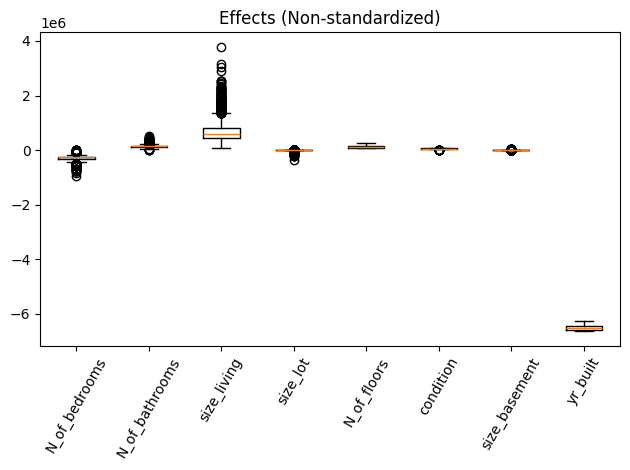

{'whiskers': [<matplotlib.lines.Line2D at 0x745eb69f51d0>,
 'caps': [<matplotlib.lines.Line2D at 0x745eb69f5450>,
 'boxes': [<matplotlib.lines.Line2D at 0x745eb69f5090>,
 'medians': [<matplotlib.lines.Line2D at 0x745eb69f56d0>,
 'fliers': [<matplotlib.lines.Line2D at 0x745eb69f5810>,
 'means': []}

([<matplotlib.axis.XTick at 0x745eb6828e10>,
 [Text(1, 0, 'N_of_bedrooms'),
  Text(2, 0, 'N_of_bathrooms'),
  Text(3, 0, 'size_living'),
  Text(4, 0, 'size_lot'),
  Text(5, 0, 'N_of_floors'),
  Text(6, 0, 'condition'),
  Text(7, 0, 'size_basement'),
  Text(8, 0, 'yr_built')])

Text(0.5, 1.0, 'Effects (Standardized)')

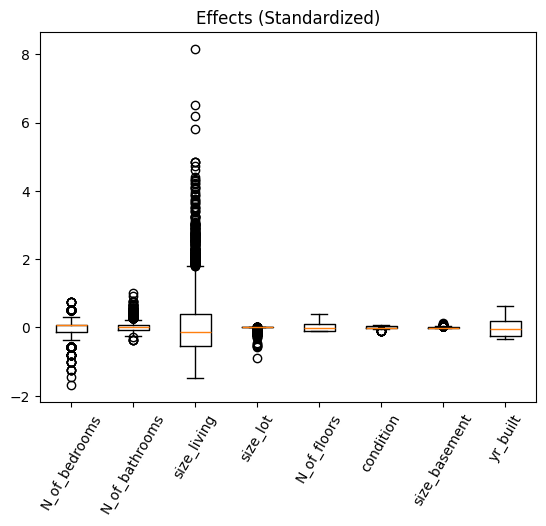

In [34]:
# non-standardized
effects: np.ndarray = None  # dimensionality n x N (every feature for every data sample)
# YOUR SOLUTION HERE
effects = X_train.values * regression.coef_
# plotting
plt.boxplot(effects)
plt.xticks(range(1, len(FEATURE_COLUMNS)+1), FEATURE_COLUMNS, rotation=60)  
plt.title("Effects (Non-standardized)")  
plt.tight_layout()  
plt.show()
# YOUR SOLUTION HERE

# standardized
effects_scaled: np.ndarray = None  # dimensionality n x N (every feature for every data sample)
# YOUR SOLUTION HERE
effects_scaled = X_train_scaled * regression_scaled.coef_
# plotting
plt.boxplot(effects_scaled)
plt.xticks(range(1, len(FEATURE_COLUMNS)+1), FEATURE_COLUMNS, rotation=60)  
plt.title("Effects (Standardized)")  
plt.show()
# YOUR SOLUTION HERE

In [35]:
# (hidden automatic tests)

## 1.4 Interpreting Effects (1 pt)

Now we can use the effects for more insights:
1. Are the effects of the features on the prediction large compared to the output ranges $y$?
2. Which features have outliers?
3. Are interquartile ranges of all features similar?
4. Is there are feature effects proportional to feature coefficients' values?
5. Are the same features most important features in terms of an effect in both models?
6. Conclusion: How successfull are effects compared to plain weights and in general in compensating unscaled features? Can one use arbitrary scaling and end up with the same feature effects?

YOUR ANSWER HERE
1. Yes especially the effects of the size_living due to the large values for this input.# either "it depends" or "no" -> -0.5 at least
2. N_of_bedrooms, N_of_bathrooms & size_living have noticeable outliers (all 3 especially noticeable in the standardized plot).
3. No, especially size_living has both massive outliers in its effects and large average values (several orders of magnitude above the other features - non-standardized) making every other remaining feature's effect appear similar, and in the standardized version the other efects are compressed very close to 0 compared to size_living but remain somewhat readable in their effects (i.e. N_of_bedrooms).
4. Assuming "Are feature effects proportional to feature cofficients' values?" was the correct question: Not strictly but in a general sense yes as the feature_value*coefficient_multiplier determine the effect. I.e. even a large coefficient could result in small effects of a feature compared to a significant large value with a smaller multiplier like in the case of size_living, especially when looking at significant outliers (there may be other features and feature-combinations at play).
5. Yes in general size_living >> yr_built > N_of_bedrooms > rest, the non-standardized plot appears more easily readable for determining the feature importance.
6. a) Significantly more useful and successful in making the feature effects on price actually directly readable and comparable to each other instead of just reading arbitrary coefficients and relying on guesses or calculations for every feature to have human-usable intuitive insights from coefficients. b) No because the input values are STANDARDized with the StandardScaler and not just mulitplied & easily multipliable inversely in their cofficients to maintain effects.

## 1.5 Explaining individual predictions (1.5 + 0.5 pts)

Now let's have a look at the feature effects of an individual sample, to see whether it has some considerably high or low feature effects compared to the average feature effects of the model.

For that determine the instance effects of the model, and for visualization add its instance effect values to the global effects plot from above as individual points.
1. How much has each feature of an instance contributed to the prediction relative to the others: Which are most contributing features?
2. Are any of the feature instance effects outliers when compared to the mean effect over the data? Do outlier properties differ between models trained on scaled and unscaled data?

Explain the results in the textual (markdown) field below the code field. 

{'whiskers': [<matplotlib.lines.Line2D at 0x745eb677f4d0>,
 'caps': [<matplotlib.lines.Line2D at 0x745eb677f750>,
 'boxes': [<matplotlib.lines.Line2D at 0x745eb677f390>,
 'medians': [<matplotlib.lines.Line2D at 0x745eb677f9d0>,
 'fliers': [<matplotlib.lines.Line2D at 0x745eb677fb10>,
 'means': []}

([<matplotlib.axis.XTick at 0x745eb677d090>,
 [Text(1, 0, 'N_of_bedrooms'),
  Text(2, 0, 'N_of_bathrooms'),
  Text(3, 0, 'size_living'),
  Text(4, 0, 'size_lot'),
  Text(5, 0, 'N_of_floors'),
  Text(6, 0, 'condition'),
  Text(7, 0, 'size_basement'),
  Text(8, 0, 'yr_built')])

Text(0.5, 1.0, 'Effects (Non-standardized)')

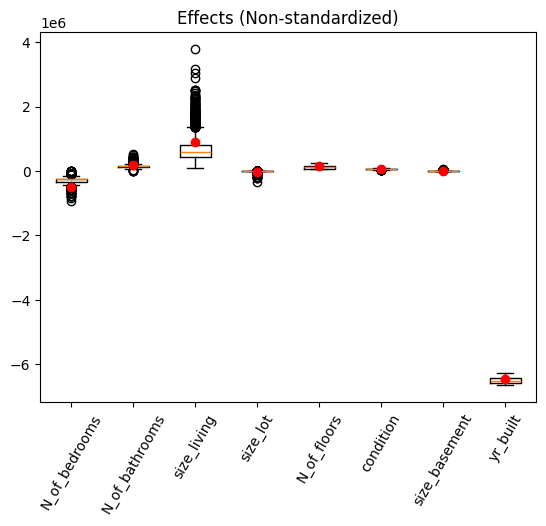

{'whiskers': [<matplotlib.lines.Line2D at 0x745eb66b5950>,
 'caps': [<matplotlib.lines.Line2D at 0x745eb66b5bd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x745eb66b5810>,
 'medians': [<matplotlib.lines.Line2D at 0x745eb66b5e50>,
 'fliers': [<matplotlib.lines.Line2D at 0x745eb66b5f90>,
 'means': []}

([<matplotlib.axis.XTick at 0x745eb667f4d0>,
 [Text(1, 0, 'N_of_bedrooms'),
  Text(2, 0, 'N_of_bathrooms'),
  Text(3, 0, 'size_living'),
  Text(4, 0, 'size_lot'),
  Text(5, 0, 'N_of_floors'),
  Text(6, 0, 'condition'),
  Text(7, 0, 'size_basement'),
  Text(8, 0, 'yr_built')])

Text(0.5, 1.0, 'Effects (Standardized)')

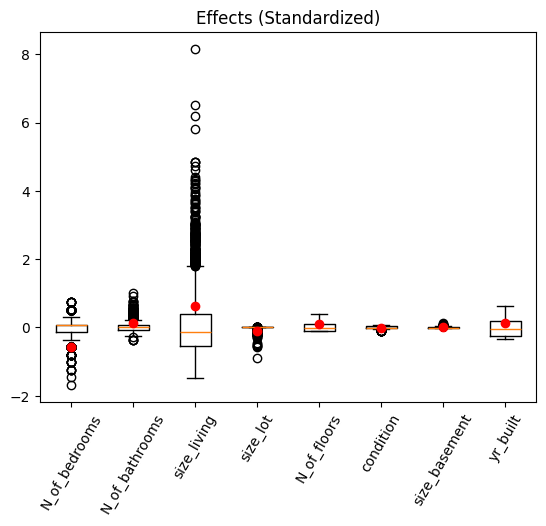

In [36]:
instance_id = 1

# YOUR SOLUTION HERE
instance_effects = X_train.iloc[instance_id].values*regression.coef_
plt.boxplot(effects)
plt.scatter(range(1, len(FEATURE_COLUMNS)+1), instance_effects, color='red', zorder=3)
plt.xticks(range(1, len(FEATURE_COLUMNS)+1), FEATURE_COLUMNS, rotation=60)  
plt.title("Effects (Non-standardized)")  
plt.show()

#instance_effects_scaled = X_train_scaled[instance_id].iloc.values*regression_scaled.coef_
instance_effects_scaled = X_train_scaled[instance_id] * regression_scaled.coef_  
plt.boxplot(effects_scaled)
plt.scatter(range(1, len(FEATURE_COLUMNS)+1), instance_effects_scaled, color='red', zorder=3)
plt.xticks(range(1, len(FEATURE_COLUMNS)+1), FEATURE_COLUMNS, rotation=60)  
plt.title("Effects (Standardized)")  
plt.show()



YOUR ANSWER HERE
1. How much has each feature of an instance contributed to the prediction relative to the others: Which are most contributing features?
The features N_of_bedrooms (negative, outlier), size_living (positive, slight outlier) contributed the most/similar values to the effect, with N_of_bathrooms(positive, slight outlier) as the 3rd highest factor. All other features contributed close to the same value (near 0) to the total  effect individually and are either within the mean or barely outside.
3. Are any of the feature instance effects outliers when compared to the mean effect over the data? Do outlier properties differ between models trained on scaled and unscaled data?
Yes N_of_bedrooms, N_of_bathrooms, size_living appear to be outliers on the standardized effects plot. They don't seem to differ between the 2 models but they are much easier to identify as outliers in the standardized plot.

# 2. Decision Trees (6 pts)

A common machine learning model are Decision Trees. Many useful implementations of this learning algorithm and models exist, e.g., in sklearn, where a convenient interface to access feature importances (`feature_importances_`) of a trained model is included: https://scikit-learn.org/stable/modules/tree.html. 

## 2.1 Training and Viewing Decision Trees (1.5 pts)
Train a single regression decision tree (choose a depth $\geq 3$) on the loaded data from above and explain your model with the help of the insights from the tree structure:
Print out the number of input features, the number of outputs, and plot the tree structure.

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

Number of input features: 8
Number of outputs: 1


<Figure size 2400x2400 with 0 Axes>

[Text(0.5865384615384616, 0.9285714285714286, 'size_living <= 316.43\nsquared_error = 147359336784.854\nsamples = 10083\nvalue = 544631.815'),
 Text(0.3076923076923077, 0.7857142857142857, 'size_living <= 200.485\nsquared_error = 54975309829.863\nsamples = 9217\nvalue = 478768.747'),
 Text(0.44711538461538464, 0.8571428571428572, 'True  '),
 Text(0.15384615384615385, 0.6428571428571429, 'size_living <= 134.895\nsquared_error = 26362387335.258\nsamples = 6056\nvalue = 397895.517'),
 Text(0.07692307692307693, 0.5, 'size_lot <= 511.245\nsquared_error = 18426203468.759\nsamples = 2652\nvalue = 343483.792'),
 Text(0.038461538461538464, 0.35714285714285715, 'size_living <= 84.075\nsquared_error = 17273679711.994\nsamples = 1177\nvalue = 392267.231'),
 Text(0.019230769230769232, 0.21428571428571427, 'size_living <= 72.925\nsquared_error = 10550237511.089\nsamples = 203\nvalue = 307974.005'),
 Text(0.009615384615384616, 0.07142857142857142, 'squared_error = 10226395793.598\nsamples = 88\nvalue

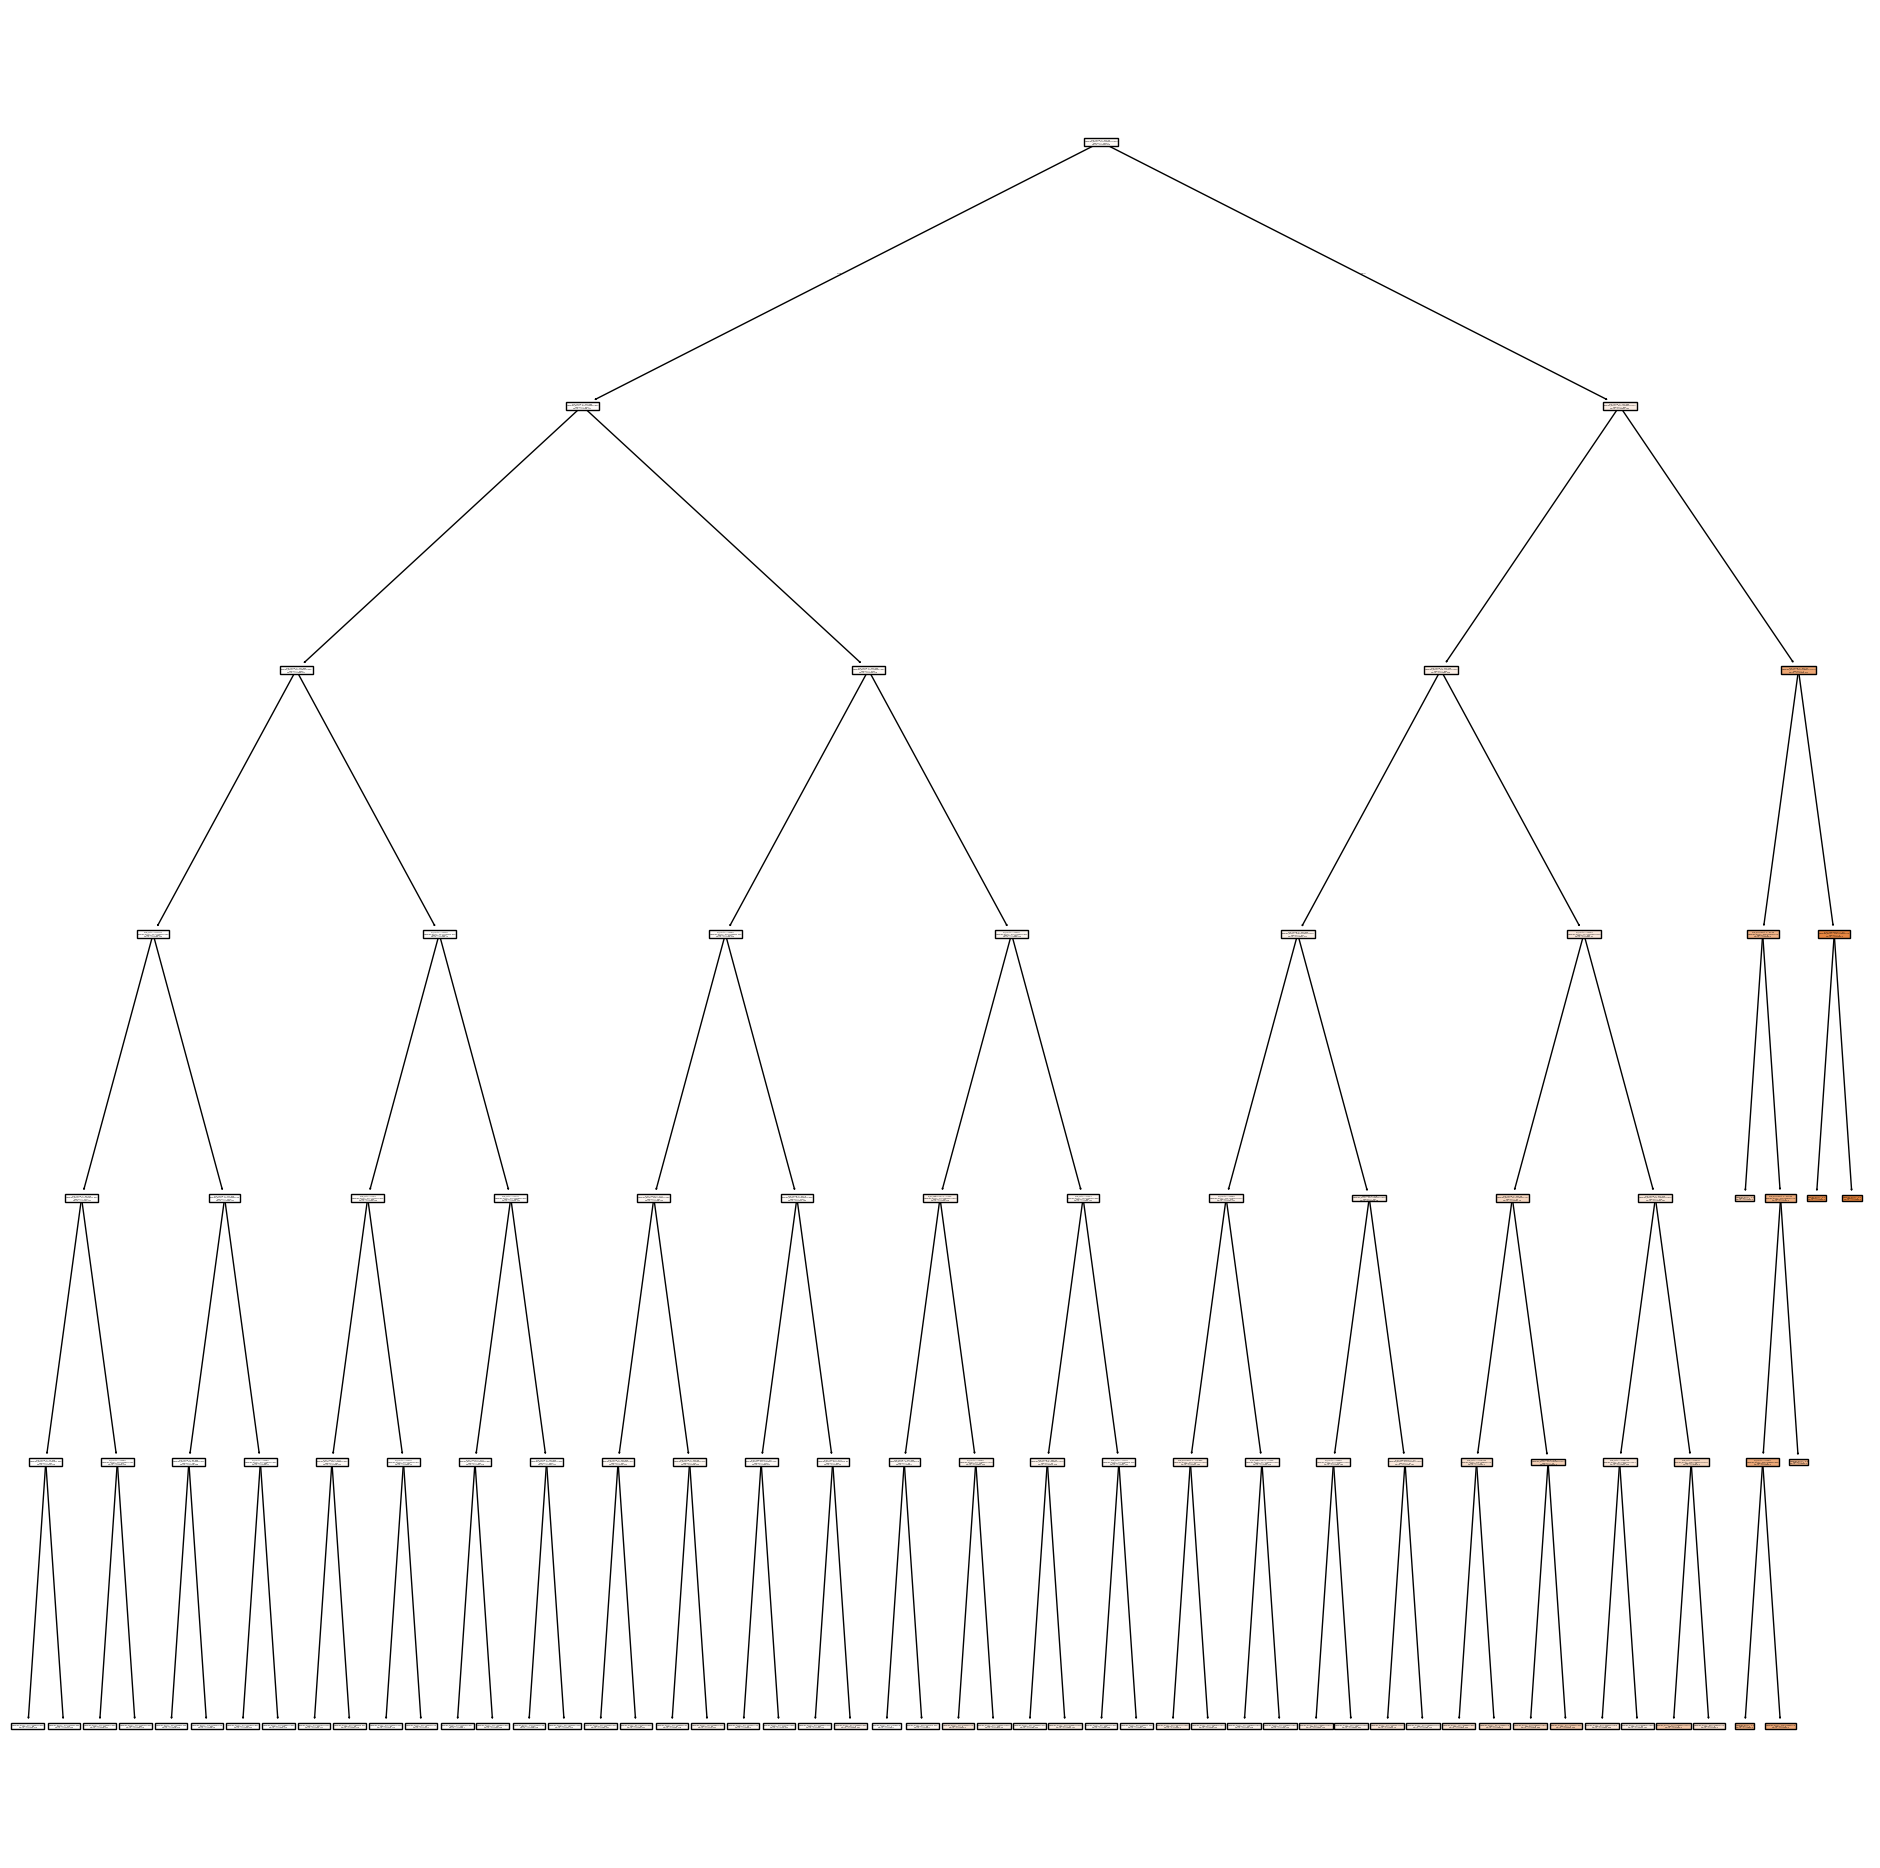

In [49]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
# YOUR SOLUTION HERE
tree_regressor = DecisionTreeRegressor(max_depth=6, random_state=42)
tree_regressor.fit(X_train, y_train)

print("Number of input features:", tree_regressor.n_features_in_);
print("Number of outputs:", tree_regressor.n_outputs_)

plt.figure(figsize=(24,24))  # set plot size for visibility
plot_tree(tree_regressor, feature_names=FEATURE_COLUMNS, filled=True)


## 2.2 Decision Tree Feature Importance (0.5 pt)
Plot the feature importances of the trained tree model.

<BarContainer object of 8 artists>

([<matplotlib.axis.XTick at 0x745eb5b7dd10>,
 [Text(0, 0, 'N_of_bathrooms'),
  Text(1, 0, 'N_of_floors'),
  Text(2, 0, 'N_of_bedrooms'),
  Text(3, 0, 'size_basement'),
  Text(4, 0, 'condition'),
  Text(5, 0, 'size_lot'),
  Text(6, 0, 'yr_built'),
  Text(7, 0, 'size_living')])

Text(0.5, 1.0, 'Decision Tree Feature Importances')

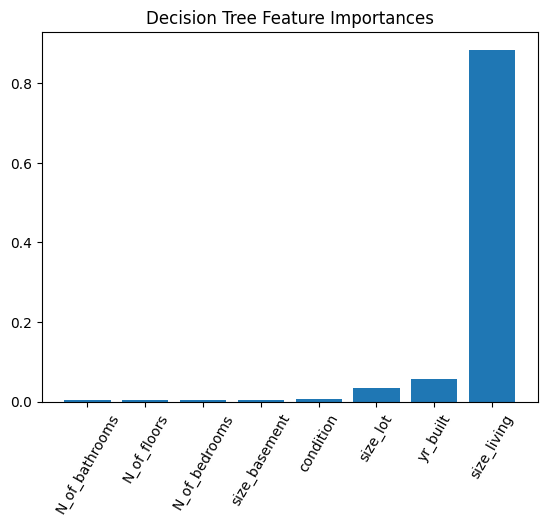

In [51]:
# YOUR SOLUTION HERE
import numpy as np
feature_importances = tree_regressor.feature_importances_
indices = np.argsort(feature_importances)

plt.bar(range(len(feature_importances)), feature_importances[indices])
plt.xticks(range(len(feature_importances)), np.array(FEATURE_COLUMNS)[indices], rotation=60)
plt.title("Decision Tree Feature Importances")
plt.show()

## 2.3 Comparing Linear and Tree Regressors: Global Case (0.5 pt)
Are the importances different to the coefficients and effects from the linear models from above task?

YOUR ANSWER HERE<br>
Yes:<br>
-the linear model effects are a relationship of the feature to output effects i.e. "increase size_living by 10 -> increase output by 100".<br>
-in decision trees the importances are a metric for determining how "useful" each feature is for correctly predicting the target outcome (i.e. correct home price range).

## 2.4 Explain individual predictions (3 pts)
How much has each feature of an instance contributed to the prediction?
We have seen that this can be calculated by the split criterion. Implement a slightly easier version of that in the following, by aggregating the split importances of splits belonging to a feature.

Choose the same instance as above for the linear model and compute individual feature importances for that instance based on the decision tree. Print out feature importances and the produced rules. Plot individual feature importances.

/opt/conda/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


Rule at node 0: (X[967, 'size_living'] = 234.120) ≤ 316.430
Rule at node 1: (X[967, 'size_living'] = 234.120) > 200.485
Rule at node 33: (X[967, 'size_living'] = 234.120) ≤ 262.455
Rule at node 34: (X[967, 'yr_built'] = 1979.000) > 1956.500
Rule at node 42: (X[967, 'size_living'] = 234.120) ≤ 237.600
Rule at node 43: (X[967, 'N_of_bedrooms'] = 4.000) > 2.500

Local Feature Importances:
N_of_bedrooms:	 0.136
N_of_bathrooms:	 0.000
size_living:	 0.130
size_lot:	 0.000
N_of_floors:	 0.000
condition:	 0.000
size_basement:	 0.000
yr_built:	 0.733


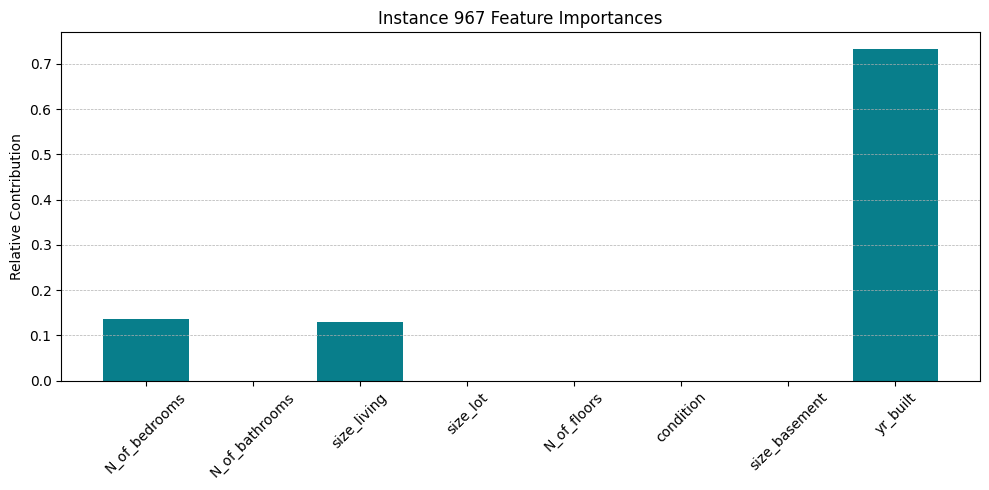

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# Define instance and dataset used
instance_id = 967
x_instance = X_train.iloc[instance_id].values

def print_node_rule(parent_node_id, instance_id, feature_index, threshold_val):
    """Convenience function to nicely print the rule applied at a splitting node."""
    go_left = (x_instance[feature_index] <= threshold_val)
    print(f"Rule at node {parent_node_id}: (X[{instance_id}, '{FEATURE_COLUMNS[feature_index]}'] = {x_instance[feature_index]:.3f}) "
              f"{'≤' if go_left else '>'} {threshold_val:.3f}")


def dt_local_absolute_relative_feature_importance(tree_regressor: DecisionTreeRegressor, x_instance: np.ndarray, X_train = X_train):
    """Calculate the local feature importance for a regression tree using the following algorithm:

    Traverse the splits along the decision path,
    assign each split as contribution the change in prediction value when descending into it,
    and aggregate as feature importance the split importances that belong to that feature.
    """

    feature_contributions = np.zeros(len(FEATURE_COLUMNS))  # values to be filled

    # some accessors for convenience
    tree = tree_regressor.tree_  # the tree structure object
    tree_values = tree.value.squeeze()  # the output values per node
    tree_features = tree.feature  # per node the index of the feature on which the the node split had been made
    tree_thresholds = tree.threshold  # per node the applied splitting threshold

    # YOUR SOLUTION HERE
    node_indicator = tree_regressor.decision_path(x_instance.reshape(1,-1))
    node_index = node_indicator.indices

    for i in range(len(node_index) -1):
        parent = node_index[i]
        child = node_index[i+1]
        feature_index = tree_features[parent]
        threshold = tree_thresholds[parent]
        print_node_rule(parent, instance_id, feature_index, threshold)
        contribution = tree_values[child] - tree_values[parent]

        if feature_index >= 0:
            feature_contributions[feature_index] += contribution
    
    # Take absolute and normalize contributions for relative comparison
    abs_contributions = np.abs(feature_contributions)
    relative_importance = abs_contributions / abs_contributions.sum()
    
    return relative_importance


# Print and plot feature importances
relative_importance = dt_local_absolute_relative_feature_importance(tree_regressor, x_instance)
print('\nLocal Feature Importances:')
for fname, rel_imp in zip(FEATURE_COLUMNS, relative_importance):
    print(f"{fname}:\t {rel_imp:.3f}")    

# Plot
_ = plt.figure(figsize=(10, 5))
_ = plt.bar(X_train.columns, relative_importance, color='#087E8B')
_ = plt.title(f'Instance {instance_id} Feature Importances')
_ = plt.xticks(rotation=45)
_ = plt.ylabel('Relative Contribution')
_ = plt.grid(True, axis='y', linestyle='--', linewidth=0.5)
_ = plt.tight_layout()
plt.show()

In [40]:
# (hidden automatic tests)

## 2.5 Comparing Linear and Tree Regressors: Local Case (0.5 pt)
Compare the result on the chosen instance with the result on the same instance obtained in the linear models from the previous task.

YOUR ANSWER HERE<br>
The results suggest a similarity between the previously observed significant "out-scaling" of the size_living parameter in linear model effect vs all other parameters and it being the most important deciding factor in the decision tree feautre importance plot.
edit: for the decision path taken, did the split result in a more or less (pos/neg) well classified split after